# Agentic RAG with LangGraph and ChromaDB

RAG（Retrieval-Augmented Generation）會先從知識庫找出相關資料，再要求 LLM 根據資料回答。

Agentic RAG 進一步讓 LLM 決定：

1. 這個問題是否需要查知識庫？
2. 找到的資料是否真的相關？
3. 如果不相關，是否要改寫問題後重新搜尋？

本例會先練習 ChromaDB 檢索與基本 RAG，再把它組成 LangGraph Agentic RAG 工作流。

## Agentic RAG 流程

```text
                         ┌─ 不需要檢索 → Direct Answer → END
START → Route Question ──┤
                         └─ 需要檢索 → Retrieve → Grade Documents
                                                   ├─ 相關 → Generate → END
                                                   ├─ 不相關 → Rewrite → Retrieve
                                                   └─ 超過重試上限 → Cannot Answer → END
```

## 1. Import libraries

In [1]:
import os
from typing import List, Literal, TypedDict

import chromadb
from IPython.display import Image, display
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

## 2. 建立 LLM 與 Embedding Model

請先設定系統環境變數 `OPENAI_API_KEY`。可選擇設定：

- `OPENAI_MODEL`：聊天模型，預設 `gpt-4o-mini`。
- `OPENAI_EMBEDDING_MODEL`：Embedding 模型，預設 `text-embedding-3-small`。
- `OPENAI_BASE_URL`：自訂 API endpoint。

In [2]:
api_key = os.environ["OPENAI_API_KEY"]
base_url = os.getenv("OPENAI_BASE_URL")

llm_options = {
    "api_key": api_key,
    "model": os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    "temperature": 0.0,
}
embedding_options = {
    "api_key": api_key,
    "model": os.getenv("OPENAI_EMBEDDING_MODEL", "text-embedding-3-small"),
}

if base_url:
    llm_options["base_url"] = base_url
    embedding_options["base_url"] = base_url

llm = ChatOpenAI(**llm_options)
embeddings = OpenAIEmbeddings(**embedding_options)

## 3. 準備小型知識庫

每個 `Document` 都包含文字內容與 metadata。真實專案通常會先讀取 PDF、網頁或內部文件，再切成較小的 chunks。

In [3]:
documents = [
    Document(
        page_content=(
            "LangGraph 的 State 是工作流程中所有節點共享的資料。"
            "Node 可以讀取 State，並以字典回傳需要更新的欄位。"
        ),
        metadata={"topic": "state", "source": "course-note-1"},
    ),
    Document(
        page_content=(
            "LangGraph 的 Node 代表一個處理步驟，Edge 則定義節點的執行方向。"
            "Conditional Edge 可以根據 State 動態選擇下一個節點。"
        ),
        metadata={"topic": "node-edge", "source": "course-note-2"},
    ),
    Document(
        page_content=(
            "MemorySaver 是記憶體內的 checkpointer。它會依 thread_id 保存 Graph checkpoint，"
            "讓多次呼叫可以延續同一個工作流程；Python 程序結束後資料會消失。"
        ),
        metadata={"topic": "memory", "source": "course-note-3"},
    ),
    Document(
        page_content=(
            "Human-in-the-Loop 可以用 interrupt_before 在敏感節點執行前暫停。"
            "人工核准後，以相同 thread_id 和 input=None 恢復工作流程。"
        ),
        metadata={"topic": "human-in-the-loop", "source": "course-note-4"},
    ),
    Document(
        page_content=(
            "ReAct Agent 讓模型在推理過程中選擇工具。ToolNode 負責執行工具，"
            "工具結果會以 ToolMessage 回到模型，直到模型產生最終答案。"
        ),
        metadata={"topic": "react", "source": "course-note-5"},
    ),
]

document_ids = [f"doc-{index}" for index in range(1, len(documents) + 1)]

## 4. 建立 ChromaDB Vector Store

本例使用記憶體內的 `EphemeralClient`，重新啟動 kernel 後資料會消失。加入文件時，Embedding Model 會將文字轉換成向量。

In [4]:
chroma_client = chromadb.EphemeralClient()

vector_store = Chroma(
    client=chroma_client,
    collection_name="agentic-rag-course",
    embedding_function=embeddings,
)

vector_store.add_documents(
    documents=documents,
    ids=document_ids,
)

print("Documents in ChromaDB:", vector_store._collection.count())

Documents in ChromaDB: 5


## 5. 練習語意檢索

相似度搜尋不是單純比對關鍵字，而是比較 query 與文件 embedding 的語意距離。Chroma 的 distance 通常越小表示越相似。

In [5]:
query = "如何讓流程停下來等待人類同意？"
results = vector_store.similarity_search_with_score(query=query, k=2)

for document, distance in results:
    print(f"Distance: {distance:.4f}")
    print(f"Metadata: {document.metadata}")
    print(document.page_content)
    print("---")

Distance: 0.9283
Metadata: {'topic': 'human-in-the-loop', 'source': 'course-note-4'}
Human-in-the-Loop 可以用 interrupt_before 在敏感節點執行前暫停。人工核准後，以相同 thread_id 和 input=None 恢復工作流程。
---
Distance: 1.4134
Metadata: {'topic': 'react', 'source': 'course-note-5'}
ReAct Agent 讓模型在推理過程中選擇工具。ToolNode 負責執行工具，工具結果會以 ToolMessage 回到模型，直到模型產生最終答案。
---


## 6. 建立基本 RAG Chain

基本 RAG 的流程固定為 Retrieve → Generate，不會自行判斷是否需要檢索，也不會檢查取回的文件。

In [6]:
rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "你是課程助教。只能根據提供的 Context 回答；"
            "若 Context 沒有答案，就明確說不知道。回答請使用繁體中文。",
        ),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)

rag_chain = rag_prompt | llm | StrOutputParser()

In [7]:
retriever = vector_store.as_retriever(search_kwargs={"k": 2})
retrieved_documents = retriever.invoke(query)
context = "\n\n".join(document.page_content for document in retrieved_documents)

basic_rag_answer = rag_chain.invoke(
    {"question": query, "context": context}
)
print(basic_rag_answer)

要讓流程停下來等待人類同意，可以在敏感節點執行前使用 `interrupt_before` 來暫停流程。然後，當人類進行人工核准後，可以以相同的 `thread_id` 和 `input=None` 來恢復工作流程。這樣就能有效地在需要人類同意的時候暫停並等待。


## 7. 定義 Agentic RAG State 與結構化決策

In [8]:
class AgenticRAGState(TypedDict):
    original_question: str
    question: str
    route: str
    route_reason: str
    documents: List[Document]
    context_relevant: bool
    grade_reason: str
    retrieval_attempts: int
    answer: str

In [9]:
class RouteDecision(BaseModel):
    use_retrieval: bool = Field(description="是否需要查詢課程知識庫")
    reason: str = Field(description="選擇此路由的簡短理由")


class RelevanceDecision(BaseModel):
    relevant: bool = Field(description="文件是否包含回答問題所需的資訊")
    reason: str = Field(description="相關或不相關的簡短理由")


route_llm = llm.with_structured_output(RouteDecision)
grader_llm = llm.with_structured_output(RelevanceDecision)

## 8. 建立 Agentic RAG Nodes

In [10]:
def route_question(state: AgenticRAGState):
    decision = route_llm.invoke(
        [
            SystemMessage(
                "判斷問題是否需要查詢 LangGraph 課程知識庫。"
                "LangGraph、State、Node、Edge、memory、human-in-the-loop、ReAct 等課程問題要檢索；"
                "問候、閒聊與簡單常識可以直接回答。"
            ),
            HumanMessage(state["question"]),
        ]
    )

    route = "retrieve" if decision.use_retrieval else "direct"
    print(f"Route: {route} — {decision.reason}")
    return {"route": route, "route_reason": decision.reason}

In [11]:
def retrieve(state: AgenticRAGState):
    retrieved = retriever.invoke(state["question"])
    attempt = state["retrieval_attempts"] + 1
    print(f"Retrieve attempt {attempt}: {len(retrieved)} documents")
    return {"documents": retrieved, "retrieval_attempts": attempt}

In [12]:
def grade_documents(state: AgenticRAGState):
    context = "\n\n".join(document.page_content for document in state["documents"])
    decision = grader_llm.invoke(
        [
            SystemMessage(
                "判斷檢索文件是否包含足以回答問題的資訊。"
                "只評估資訊相關性，不要回答原問題。"
            ),
            HumanMessage(
                f"Question: {state['question']}\n\nDocuments:\n{context}"
            ),
        ]
    )

    print(f"Relevant: {decision.relevant} — {decision.reason}")
    return {
        "context_relevant": decision.relevant,
        "grade_reason": decision.reason,
    }

In [13]:
def rewrite_question(state: AgenticRAGState):
    response = llm.invoke(
        [
            SystemMessage(
                "請把使用者問題改寫成適合向量資料庫搜尋的精簡查詢。"
                "保留原意，只輸出改寫後的查詢。"
            ),
            HumanMessage(
                f"Original question: {state['original_question']}\n"
                f"Current query: {state['question']}\n"
                f"Why documents were irrelevant: {state['grade_reason']}"
            ),
        ]
    )

    rewritten = response.content.strip()
    print("Rewritten query:", rewritten)
    return {"question": rewritten}

In [14]:
def generate_answer(state: AgenticRAGState):
    context = "\n\n".join(
        f"Source: {document.metadata['source']}\n{document.page_content}"
        for document in state["documents"]
    )
    answer = rag_chain.invoke(
        {"question": state["original_question"], "context": context}
    )
    return {"answer": answer}

In [15]:
def direct_answer(state: AgenticRAGState):
    response = llm.invoke(
        [
            SystemMessage("請簡潔回答使用者。回答請使用繁體中文。"),
            HumanMessage(state["original_question"]),
        ]
    )
    return {"answer": response.content}

In [16]:
def cannot_answer(state: AgenticRAGState):
    return {
        "answer": (
            "知識庫中沒有足夠資料可以可靠回答這個問題。"
            f"最後的檢索判斷：{state['grade_reason']}"
        )
    }

## 9. 建立 Conditional Routers

In [17]:
MAX_RETRIEVAL_ATTEMPTS = 2


def route_after_question(state: AgenticRAGState) -> Literal["retrieve", "direct"]:
    return state["route"]


def route_after_grade(
    state: AgenticRAGState,
) -> Literal["generate", "rewrite", "cannot_answer"]:
    if state["context_relevant"]:
        return "generate"

    if state["retrieval_attempts"] < MAX_RETRIEVAL_ATTEMPTS:
        return "rewrite"

    return "cannot_answer"

## 10. 建立 Agentic RAG Graph

In [18]:
workflow = StateGraph(AgenticRAGState)

workflow.add_node("route_question", route_question)
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("direct_answer", direct_answer)
workflow.add_node("cannot_answer", cannot_answer)

workflow.add_edge(START, "route_question")
workflow.add_conditional_edges(
    "route_question",
    route_after_question,
    {"retrieve": "retrieve", "direct": "direct_answer"},
)
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    route_after_grade,
    {
        "generate": "generate_answer",
        "rewrite": "rewrite_question",
        "cannot_answer": "cannot_answer",
    },
)
workflow.add_edge("rewrite_question", "retrieve")
workflow.add_edge("generate_answer", END)
workflow.add_edge("direct_answer", END)
workflow.add_edge("cannot_answer", END)

graph = workflow.compile()

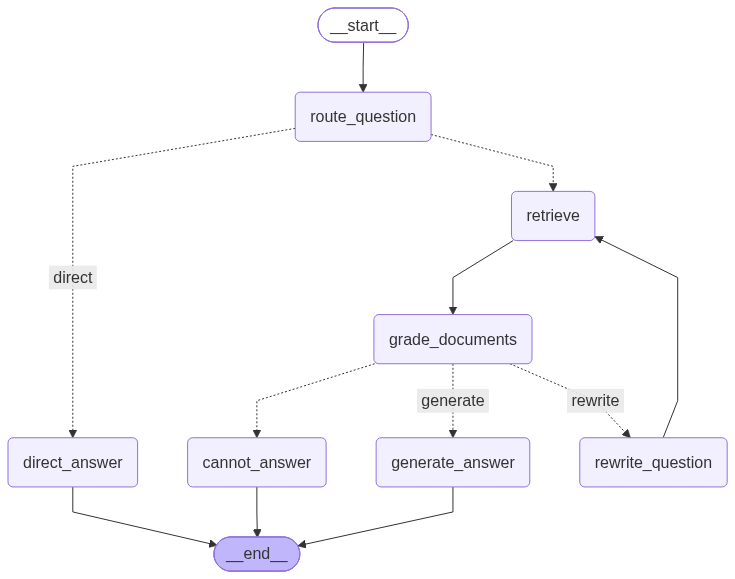

In [19]:
display(Image(graph.get_graph().draw_mermaid_png()))

## 11. 執行 Agentic RAG

使用 `stream_mode="values"` 可以觀察 State 經過各節點時的變化。

In [20]:
def run_agentic_rag(question: str):
    initial_state: AgenticRAGState = {
        "original_question": question,
        "question": question,
        "route": "",
        "route_reason": "",
        "documents": [],
        "context_relevant": False,
        "grade_reason": "",
        "retrieval_attempts": 0,
        "answer": "",
    }

    final_state = initial_state
    for event in graph.stream(
        initial_state,
        stream_mode="values",
        config={"recursion_limit": 12},
    ):
        final_state = event

    print("\nFinal answer:\n")
    print(final_state["answer"])
    return final_state

In [21]:
rag_result = run_agentic_rag(
    "LangGraph 如何讓工作流程暫停，等待人工核准後再繼續？"
)

Route: retrieve — 這個問題涉及到 LangGraph 的工作流程設計，特別是如何實現人機協作的功能，因此需要查詢相關課程知識庫以獲得準確的資訊。
Retrieve attempt 1: 2 documents
Relevant: True — 文件中提到使用 interrupt_before 在敏感節點執行前暫停工作流程，並且描述了如何在人工核准後恢復工作流程，這直接回答了問題。

Final answer:

LangGraph 可以透過在敏感節點執行前使用 `interrupt_before` 來暫停工作流程，等待人工核准。人工核准後，可以使用相同的 `thread_id` 和 `input=None` 來恢復工作流程。


## 12. 測試不需要 RAG 的問題

這類問題應由 Router 導向 Direct Answer，不執行 ChromaDB 檢索。

In [22]:
direct_result = run_agentic_rag("請用一句話跟初學者打招呼。")

Route: direct — 這是一個簡單的問候，不需要查詢課程知識庫。

Final answer:

你好！歡迎來到學習的旅程，祝你學習愉快！


## 基本 RAG 與 Agentic RAG 比較

| 能力 | 基本 RAG | Agentic RAG |
|---|---|---|
| 每次都檢索 | 是 | 否，由 Router 決定 |
| 檢查文件相關性 | 通常沒有 | 有 |
| 改寫搜尋問題 | 沒有 | 文件不相關時自動改寫 |
| 控制流程 | 固定 Chain | LangGraph Conditional Edges |
| 複雜度與成本 | 較低 | 較高，可能呼叫 LLM 多次 |

Agentic RAG 並非永遠比較好。固定且簡單的知識問答通常使用基本 RAG 即可；只有在需要路由、品質檢查或重新搜尋時，才值得使用 Agentic RAG。